<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Support_Vector_Machine/Linear_SVM_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Goal:** Build a Linear SVM from scratch using hinge loss and stochastic gradient descent on the Two Moons dataset.
### **Skills demonstrated:** NumPy, Gradient Descent (SGD), Hinge Loss, Linear Classification, Decision Boundary Visualization.

## **# 1. Introduction**
Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification. Unlike logistic regression, which focuses on estimating probabilities, SVM searches for a decision boundary that separates classes while maximizing the margin between them.

In this notebook, the model is implemented from scratch using NumPy instead of sklearn.SVC. The objective is to understand the mathematical foundation behind linear SVM before moving to kernel-based SVM.


In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Uploading the data

from sklearn.datasets import make_moons
# Instead of drawing a straight line in the original space, a kernel maps the data into a higher-dimensional space where a straight hyperplane becomes possible.
# When transformed back, that hyperplane appears as a curved boundary that follows the moon shapes.
X, Y = make_moons(n_samples=300, noise=0.15, random_state=42)

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

## **2. Understanding the Dataset**
The Two Moons dataset is a synthetic binary classification dataset consisting of two crescent-shaped clusters.

Why this dataset?

Two classes are clearly visible.

The classes are not perfectly linearly separable.

It demonstrates both the strengths and limitations of a linear SVM.

The dataset contains:

-- 300 samples

-- 2 numerical features

-- 2 classes






In [4]:
# Data Inspection

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

print("\nFirst five samples:")
print(X[:5])

print("\nUnique labels:")
print(set(Y))

Shape of X: (300, 2)
Shape of Y: (300,)

First five samples:
[[ 0.74345732 -0.31830534]
 [ 2.17771154 -0.1269264 ]
 [-0.21007181  0.45266402]
 [ 0.83759707  0.33520083]
 [ 1.18455753 -0.5045741 ]]

Unique labels:
{np.int64(0), np.int64(1)}


## **3. Visualizing the Data**
Before training any model, it's important to understand the geometry of the data.

The scatter plot reveals:

one upper crescent,

one lower crescent,

no straight line can perfectly separate every point.

This observation motivates why **kernel methods** exist.

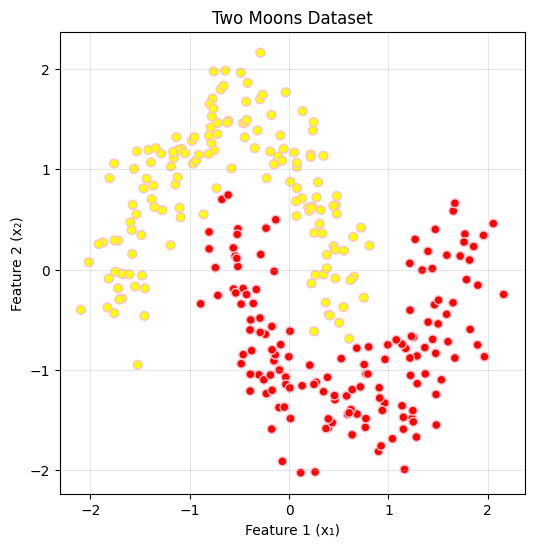

In [17]:
# Visualize the data

plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],      # x₁ coordinates
    X[:,1],      # x₂ coordinates
    c=Y,         # color according to class
    cmap="autumn_r",
    edgecolors="pink",
    s=40
)

plt.xlabel("Feature 1 (x₁)")
plt.ylabel("Feature 2 (x₂)")
plt.title("Two Moons Dataset")
plt.grid(alpha=0.3)

plt.show()

## **4. Feature Standardization**
SVM is a distance-based algorithm, so features should have comparable scales.
Instead of using StandardScaler, standardization is performed manually using NumPy.

The transformation is
**z= (x−μ) / σ**


where

μ is the feature mean,

σ is the standard deviation.

After standardization,

feature means become approximately 0,

standard deviations become approximately 1.

This prevents one feature from dominating the optimization process.


In [16]:
# Calculate mean and standard deviation for each feature
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

# Standardize
X = (X - mean) / std

print("Mean:", np.mean(X, axis=0))
print("Std:", np.std(X, axis=0))

Mean: [ 5.92118946e-16 -3.55271368e-16]
Std: [1. 1.]


## **5. Converting Labels**
The original labels are
*   0
*   1


SVM's hinge-loss formulation requires labels to be
*   -1
*   +1


The conversion is performed once using NumPy.

This allows the expression **y_i(w⋅x_i + b)** to behave correctly during optimization.

In [18]:

Y = np.where(Y == 0, -1, 1)
print(np.unique(Y, return_counts=True))

(array([-1,  1]), array([150, 150]))


In [19]:
#Initialize the parameters

# Number of features
n_features = X.shape[1]

# Initialize weights and bias
w = np.zeros(n_features)
b = 0.0

# Hyperparameters
learning_rate = 0.001
lambda_param = 0.01   # regularization strength
epochs = 1000

## **6. The Hyperplane**
A linear SVM learns a decision boundary described by
**w⋅x+b=0**

For two features, this becomes
**w1x1 + w2x2 + b = 0**

where

w controls the orientation of the boundary,

b shifts the boundary.

Classification works by evaluating
**f(x)=w⋅x+b**

*   positive → class +1
*   negative → class -1

## **7. Maximum Margin Intuition**
Unlike ordinary linear classifiers, SVM does not simply search for any separating line.

Instead, it tries to maximize the margin between the two classes.
Three important boundaries exist:

*  Decision boundary: w⋅x+b=0
*  Upper margin: w⋅x+b=1
*  Lower margin: w⋅x+b=−1

The training points touching these margins become support vectors.

Although the Two Moons dataset is not perfectly linearly separable, this margin-based optimization still forms the foundation of SVM.

## **8. Hinge Loss**
Instead of Mean Squared Error, SVM minimizes hinge loss.

For one sample,
**L_i=max(0,1−y_i(w⋅x_i+b))**

if:
*   ≥ 1 : Correct and outside the margin
*   0 to 1 : Correct but inside the margin
*   ≤ 0 : Misclassified


The complete objective is:

**1/2 ||w||^2 + λ∑L_i**

where:

the first term encourages a larger margin,

the second penalizes margin violations.




## **9. Training using Stochastic Gradient Descent**
Instead of using an optimizer from a library, the weights are updated manually.
For every training sample, two cases are checked.

**Case 1:** Margin satisfied
If

y_i(w⋅x_i+b)≥1

only regularization updates the weights.

**Case 2:** Margin violated

If

y_i(w⋅x_i+b)<1

the hinge-loss gradient updates both
the weights,
the bias.

Because parameters are updated after every sample, this implementation uses Stochastic Gradient Descent (SGD).

In [21]:
# Linear SVM
loss_history = []

for epoch in range(epochs):


    for idx, x_i in enumerate(X):

        condition = Y[idx] * (np.dot(x_i, w) + b)

        if condition >= 1:
            # Only regularization
            w = w - learning_rate * (lambda_param * w)

        else:
            # Hinge loss is active
            w = w - learning_rate * (lambda_param * w - Y[idx] * x_i)
            b = b + learning_rate * Y[idx]
    hinge_loss = np.maximum(0, 1 - Y * (np.dot(X, w) + b))

    loss = (0.5 * np.dot(w, w)) + lambda_param * np.sum(hinge_loss)
    loss_history.append(loss)

    if epoch % 100 == 0:
      print(f"Epoch {epoch}: Loss = {loss:.4f}")

Epoch 0: Loss = 2.2153
Epoch 100: Loss = 2.2151
Epoch 200: Loss = 2.2139
Epoch 300: Loss = 2.2146
Epoch 400: Loss = 2.2143
Epoch 500: Loss = 2.2131
Epoch 600: Loss = 2.2149
Epoch 700: Loss = 2.2146
Epoch 800: Loss = 2.2144
Epoch 900: Loss = 2.2142


## **10. Making Predictions**
After training, predictions are obtained by computing

**w⋅x+b**

The sign of this value determines the predicted class.

This produces labels of
*   -1
*   +1

matching the training labels

In [27]:

def predict(X):
    linear_output = np.dot(X, w) + b
    return np.sign(linear_output)


Y_pred = predict(X)

print("First 10 predictions:", Y_pred[:10])
print("First 10 true labels:", Y[:10])

First 10 predictions: [ 1.  1. -1.  1.  1.  1.  1. -1.  1.  1.]
First 10 true labels: [ 1  1  1 -1  1  1  1 -1 -1  1]


## **Observation**
The loss remained close to 2.214 throughout training with small fluctuations.

This behavior is expected because the implementation uses Stochastic Gradient Descent (SGD), where the parameters are updated after every training sample rather than after computing the gradient of the entire dataset.

As a result, the optimization does not produce a perfectly smooth decreasing loss curve.


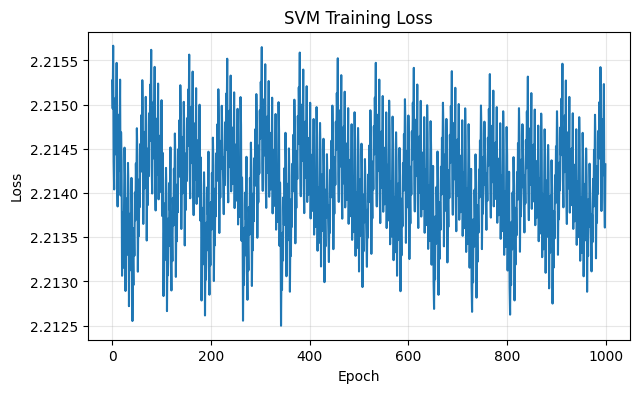

In [30]:
# PLOTTING THE LOSS
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SVM Training Loss")
plt.grid(alpha=0.3)
plt.show()

## **11. Visualizing the Learned Decision Boundary**
To understand what the model has learned, predictions are made over a dense grid covering the feature space.

The colored regions represent predicted classes, while the original training points are plotted on top.

Because this is a linear SVM, the learned boundary remains a straight line.

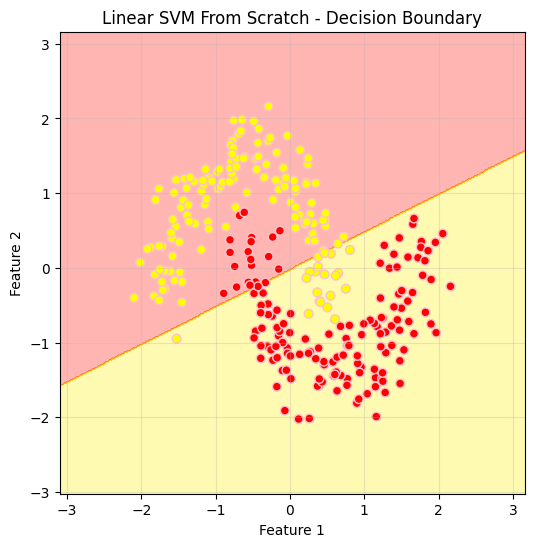

In [31]:
# Create a grid of points
X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() + 1
Y_min, Y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

XX, YY = np.meshgrid(
    np.linspace(X_min, X_max, 300),
    np.linspace(Y_min, Y_max, 300)
)

# Predict every point on the grid
grid = np.c_[XX.ravel(), YY.ravel()]
Z = predict(grid)

# Reshape predictions back into the grid shape
Z = Z.reshape(XX.shape)

# Plot decision regions
plt.figure(figsize=(6, 6))
plt.contourf(XX, YY, Z, alpha=0.3, cmap="autumn")

# Plot original data
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=Y,
    cmap="autumn_r",
    edgecolors="pink",
    s=40
)

plt.title("Linear SVM From Scratch - Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)

plt.show()

## **12. Model Evaluation**
Accuracy is computed manually using NumPy instead of sklearn.metrics.

Training accuracy measures performance on the data used during training, while test accuracy evaluates performance on unseen data.

For a balanced dataset like Two Moons, test accuracy provides a more meaningful estimate of generalization.

**Training Accuracy:** ***86.67%.*** This notebook evaluates the model on the same dataset used for training because its purpose is to demonstrate how a linear SVM learns a decision boundary.

A train-test split will be introduced in the RBF Kernel SVM notebook to evaluate generalization on unseen data.

In [32]:
# Predict on the dataset
Y_pred = predict(X)
# Calculate accuracy manually
accuracy = np.mean(Y_pred == Y)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8667
Accuracy: 86.67%


## **13. Observations**
Key observations from this implementation:

*   Standardization is important for distance-based optimization.
*   Converting labels to -1 and +1 is essential for hinge loss.
*   SGD updates weights after every training sample.
*   The learned decision boundary is correctly linear.
*   The Two Moons dataset demonstrates the limitation of linear SVM and motivates kernel methods.



## **14. Conclusion**
In this notebook, a complete linear SVM was implemented from scratch using NumPy.

Instead of relying on **sklearn.SVC**, the implementation manually performed

*   feature standardization,
*   label transformation,
*   hinge-loss optimization,
*   stochastic gradient descent,
*   prediction,
*   and decision-boundary visualization.


This provides the mathematical foundation needed to build an RBF Kernel SVM from scratch in the next notebook.